In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

import os
from pathlib import Path
import sys
# Set sys path
sys.path.append(str(Path(os.getcwd()).parent))

# Set filpaths for data and figures
notebook_dir = os.getcwd()
file_path = Path(notebook_dir).parent / 'data' 

In [44]:
plt.rcParams['pdf.fonttype'] = 42  # Use Type 3 (PostScript) fonts
plt.rcParams['ps.fonttype'] = 42

In [4]:
file_path

WindowsPath('d:/Notebooks/data_viz/data')

In [5]:
# load data
df = pd.read_csv(file_path / 'Scivias_PCAN_proteins.tsv', sep='\t', index_col=0)

In [6]:
d_meta = pd.read_csv(file_path / 'Scivias_plasma_metadata.tsv', sep='\t', index_col=0)

# data structure
proteomics data with proteins as columns and samples as rows

In [7]:
df

,A0A024R1R8;Q9Y2S6,A0A075B6H7,A0A075B6I0,A0A075B6I9,A0A075B6J1,A0A075B6J9,A0A075B6K0,A0A075B6K2,A0A075B6K4,A0A075B6K5,...,Q9Y646,Q9Y653-5,Q9Y6C2,Q9Y6F6-3;Q9Y6F6-5,Q9Y6I9,Q9Y6M7-12;Q9Y6M7-8,Q9Y6R7,Q9Y6W3,Q9Y6Y9,Q9Y6Z7
P01_A01,NaN,4.458457,5.312050,4.578302,3.181054,4.198316,3.983582,2.837581,5.277082,5.144518,...,3.642569,3.600890,NaN,NaN,NaN,4.446380,4.541751,4.063754,3.215638,4.340569
P01_A02,4.163072,4.208619,5.558028,4.381431,NaN,4.581916,NaN,NaN,5.293024,5.225818,...,3.817016,3.669798,3.066766,NaN,NaN,NaN,4.285499,3.939671,3.349025,4.335329
P01_A03,4.000577,4.625975,5.656026,4.702237,NaN,4.900476,4.541595,NaN,5.866296,5.829046,...,4.241330,3.526185,3.177943,NaN,NaN,3.924085,4.687596,3.667681,3.253721,3.854947
P01_A04,4.209260,4.355001,4.919161,4.313156,NaN,4.330560,3.925775,3.097531,4.937413,5.542439,...,3.550006,3.529819,NaN,NaN,NaN,4.320599,4.931857,3.872847,3.298121,4.341389
P01_A05,4.078479,3.721408,4.451332,NaN,NaN,4.220370,NaN,NaN,4.691826,5.000551,...,3.916710,3.745076,3.192264,NaN,NaN,NaN,NaN,3.956799,3.415931,4.279977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P14_D12,4.384697,4.224222,5.017330,3.729440,NaN,4.474349,NaN,NaN,4.833414,4.963101,...,3.574559,3.842268,3.463251,3.373048,NaN,NaN,4.296387,4.067881,NaN,4.233757
P14_E12,4.410222,4.159790,4.955922,3.772259,NaN,4.454030,NaN,NaN,4.799068,4.923599,...,3.297542,4.016837,3.259637,2.910340,2.618121,NaN,4.310823,4.449630,NaN,4.227035
P14_F12,4.315710,3.941148,5.143080,4.283792,NaN,4.543706,NaN,NaN,4.816320,4.953364,...,3.518239,3.904196,NaN,3.418861,NaN,NaN,NaN,4.258149,NaN,4.258141
P14_G12,4.325821,4.225439,5.050990,4.178355,NaN,4.582854,NaN,NaN,4.862567,4.996329,...,3.910363,3.754565,NaN,3.151367,2.764024,NaN,4.169383,4.128629,NaN,4.300776


In [8]:
d_meta

,sct_description
index_PCAN,
P02_G09,Crohn's disease (disorder)
P02_D09,Conjunctivitis (disorder)
P02_D09,Periodic fever and aphthous stomatitis with ph...
P04_B08,Chronic nonbacterial osteomyelitis/chronic rec...
P04_B08,Crohn's disease (disorder)
...,...
P12_C07,Recurrent infectious disease (disorder)
P12_C08,Celiac disease (disorder)
P12_C09,Functional abdominal pain syndrome (disorder)


# Data exploration - understanding the data

plot histogram of protein A0A075B6H7

In [9]:
d_meta['sct_description'].value_counts()

sct_description
Well child (finding)                                                                111
Cystic fibrosis (disorder)                                                           76
Celiac disease (disorder)                                                            65
Diabetes mellitus type 1 (disorder)                                                  27
Crohn's disease (disorder)                                                           24
                                                                                   ... 
Congenital anomaly of blood vessel of lower limb (disorder)                           1
Gastritis (disorder)                                                                  1
Chronic pancreatitis (disorder)                                                       1
Acute glomerulonephritis due to and following streptococcal infection (disorder)      1
Cerebellar infarction (disorder)                                                      1
Name: count, Len

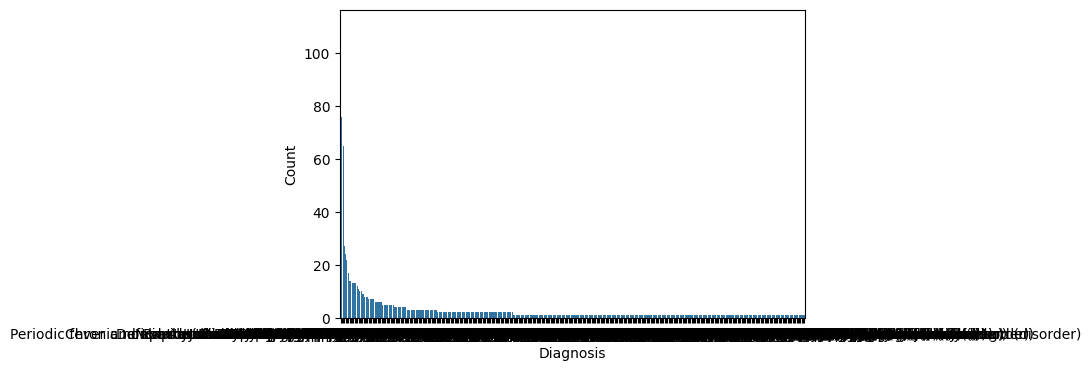

In [10]:
plt.figure(figsize=(6, 4))
sns.barplot(d_meta['sct_description'].value_counts())
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

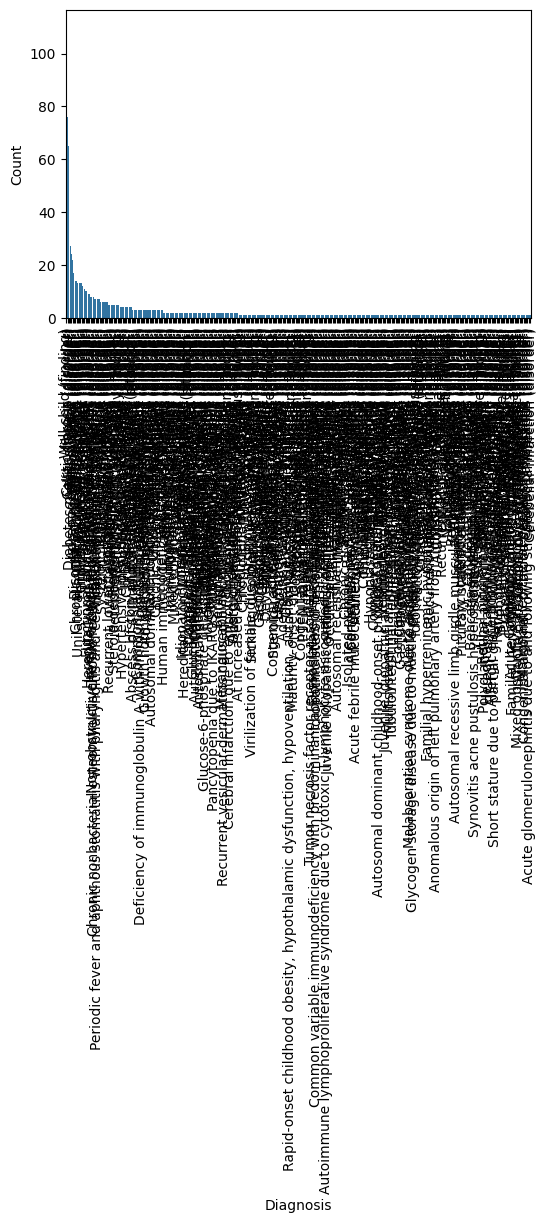

In [11]:
plt.figure(figsize=(6, 4))
sns.barplot(d_meta['sct_description'].value_counts())
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

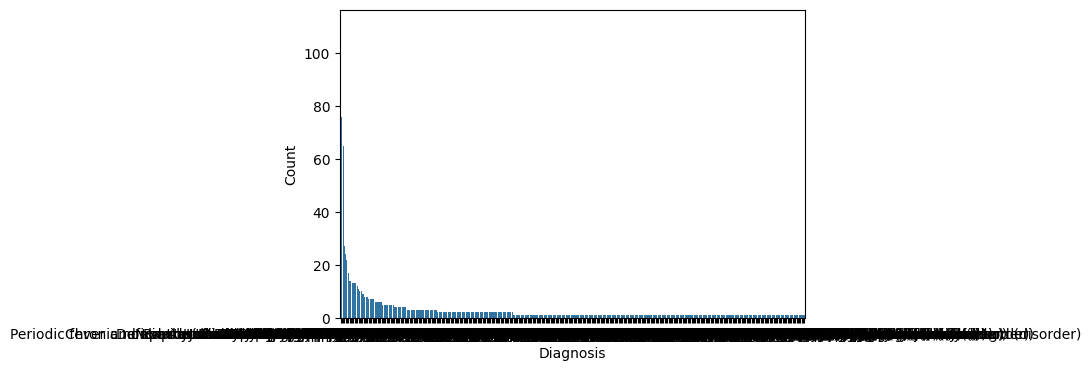

In [12]:
plt.figure(figsize=(6, 4))
sns.barplot(d_meta['sct_description'].value_counts())
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks()
plt.show()

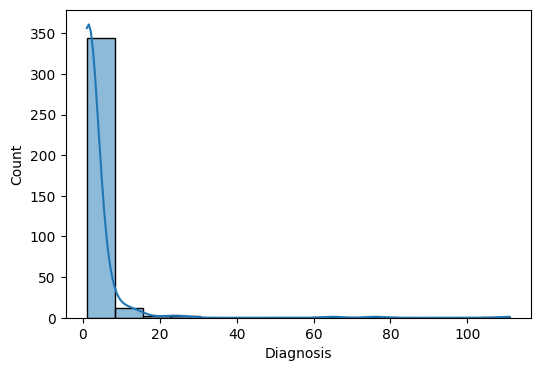

In [13]:
plt.figure(figsize=(6, 4))
sns.histplot(d_meta['sct_description'].value_counts(), bins=15, kde=True)
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [14]:
d_merge = pd.merge(d_meta, df, left_index=True, right_index=True)  

In [15]:
d_merge.iloc[:,:6].reset_index()

,index_PCAN,sct_description,A0A024R1R8;Q9Y2S6,A0A075B6H7,A0A075B6I0,A0A075B6I9,A0A075B6J1
0,P02_G09,Crohn's disease (disorder),4.365973,4.307838,5.102218,3.618045,NaN
1,P02_D09,Conjunctivitis (disorder),4.395017,4.402963,5.426513,4.751197,NaN
2,P02_D09,Periodic fever and aphthous stomatitis with ph...,4.395017,4.402963,5.426513,4.751197,NaN
3,P04_B08,Chronic nonbacterial osteomyelitis/chronic rec...,4.227213,4.627145,5.008928,3.899406,NaN
4,P04_B08,Crohn's disease (disorder),4.227213,4.627145,5.008928,3.899406,NaN
...,...,...,...,...,...,...,...
1042,P12_C07,Recurrent infectious disease (disorder),3.824615,4.277531,NaN,4.298814,NaN
1043,P12_C08,Celiac disease (disorder),4.217886,3.967218,4.762683,3.985209,NaN
1044,P12_C09,Functional abdominal pain syndrome (disorder),3.956288,4.308359,5.141835,4.357338,NaN
1045,P12_C10,Well child (finding),4.210583,4.099342,5.095047,NaN,NaN


In [16]:
df_long = d_merge.iloc[:,:6].reset_index().melt(
    id_vars=['index_PCAN', 'sct_description'], var_name='variable', value_name='value')

In [17]:
df_long

,index_PCAN,sct_description,variable,value
0,P02_G09,Crohn's disease (disorder),A0A024R1R8;Q9Y2S6,4.365973
1,P02_D09,Conjunctivitis (disorder),A0A024R1R8;Q9Y2S6,4.395017
2,P02_D09,Periodic fever and aphthous stomatitis with ph...,A0A024R1R8;Q9Y2S6,4.395017
3,P04_B08,Chronic nonbacterial osteomyelitis/chronic rec...,A0A024R1R8;Q9Y2S6,4.227213
4,P04_B08,Crohn's disease (disorder),A0A024R1R8;Q9Y2S6,4.227213
...,...,...,...,...
5230,P12_C07,Recurrent infectious disease (disorder),A0A075B6J1,NaN
5231,P12_C08,Celiac disease (disorder),A0A075B6J1,NaN
5232,P12_C09,Functional abdominal pain syndrome (disorder),A0A075B6J1,NaN
5233,P12_C10,Well child (finding),A0A075B6J1,NaN


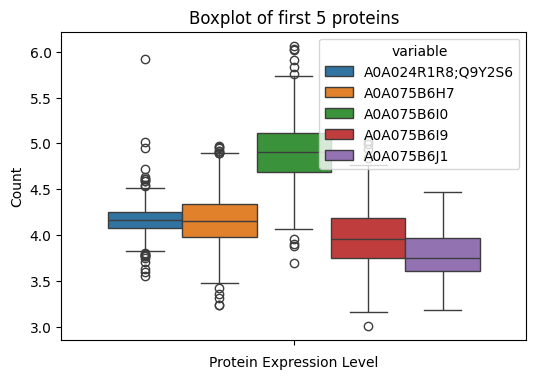

In [18]:
plt.figure(figsize=(6, 4))
sns.boxplot(df_long, y='value', hue='variable')
plt.title('Boxplot of first 5 proteins')
plt.xlabel('Protein Expression Level')
plt.ylabel('Count')
plt.show()

In [19]:
d_meta['sct_description'].value_counts().iloc[:5].index

Index(['Well child (finding)', 'Cystic fibrosis (disorder)',
       'Celiac disease (disorder)', 'Diabetes mellitus type 1 (disorder)',
       'Crohn's disease (disorder)'],
      dtype='object', name='sct_description')

In [20]:
df_long[df_long['sct_description'].isin(d_meta['sct_description'].value_counts().iloc[:5].index)]

,index_PCAN,sct_description,variable,value
0,P02_G09,Crohn's disease (disorder),A0A024R1R8;Q9Y2S6,4.365973
4,P04_B08,Crohn's disease (disorder),A0A024R1R8;Q9Y2S6,4.227213
21,P04_C06,Crohn's disease (disorder),A0A024R1R8;Q9Y2S6,4.134878
22,P03_D10,Crohn's disease (disorder),A0A024R1R8;Q9Y2S6,4.242618
30,P04_G04,Crohn's disease (disorder),A0A024R1R8;Q9Y2S6,4.058525
...,...,...,...,...
5218,P12_B08,Well child (finding),A0A075B6J1,NaN
5222,P12_B11,Well child (finding),A0A075B6J1,NaN
5228,P12_C05,Well child (finding),A0A075B6J1,NaN
5231,P12_C08,Celiac disease (disorder),A0A075B6J1,NaN


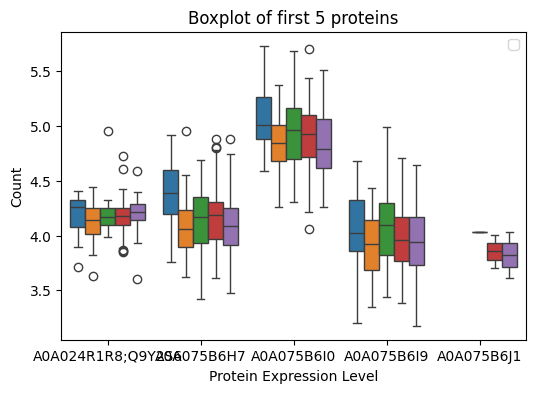

In [21]:
plt.figure(figsize=(6, 4))
sns.boxplot(df_long[df_long['sct_description'].isin(d_meta['sct_description'].value_counts().iloc[:5].index)], y='value', hue='sct_description', x='variable')
plt.title('Boxplot of first 5 proteins')
plt.xlabel('Protein Expression Level')
plt.ylabel('Count')
plt.legend([])
plt.show()

In [22]:
import plotly.express as px
fig = px.box(df_long[df_long['sct_description'].isin(d_meta['sct_description'].value_counts().iloc[:5].index)],
             y='value', color='sct_description', x='variable',
             title='Boxplot of first 5 proteins')
fig.show()

In [23]:
import plotly.express as px
fig = px.violin(df_long[df_long['sct_description'].isin(d_meta['sct_description'].value_counts().iloc[:5].index)],
             y='value', color='sct_description', x='variable',
             title='Boxplot of first 5 proteins')
fig.show()

In [24]:
import plotly.express as px
fig = px.box(df_long[df_long['sct_description'].isin(d_meta['sct_description'].value_counts().iloc[:5].index)],
             y='value', color='sct_description', x='variable',
             title='Boxplot of first 5 proteins',
             points='all')
fig.show()

# Heatmaps

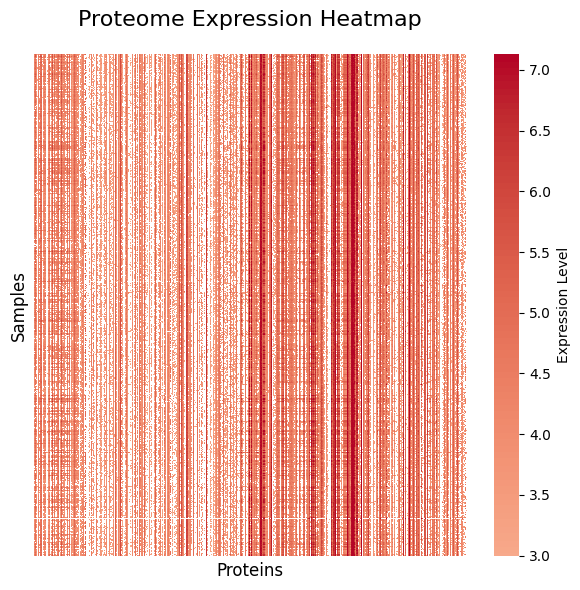

In [25]:
plt.figure(figsize=(6, 6))  # Adjust size based on your data dimensions

# Create heatmap without clustering
sns.heatmap(df.iloc[:500,:500], 
            cmap='coolwarm',          # Color scheme (alternatives: 'viridis', 'RdBu_r', 'YlOrRd')
            cbar=True,                # Show colorbar
            cbar_kws={'label': 'Expression Level'},  # Colorbar label
            xticklabels=True,         # Show protein names
            yticklabels=True,         # Show sample names
            linewidths=0.001,           # Add grid lines
            linecolor='gray',         # Grid line color
            square=False,             # Don't force square cells
            vmin=None,                # Min value for color scale (auto if None)
            vmax=None,                # Max value for color scale (auto if None)
            center=0,                 # Center of colormap (useful for diverging colormaps)
            robust=True,              # Use robust quantiles for color limits
            annot=False,              # Don't annotate cells with values (set True if needed)
            fmt='.2f')                # Format for annotations if enabled

# Customize the plot
plt.title('Proteome Expression Heatmap', fontsize=16, pad=20)
plt.xlabel('Proteins', fontsize=12)
plt.ylabel('Samples', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks([])
plt.yticks([])

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

c:\Users\jomueller\AppData\Local\anaconda3\envs\viz_env\lib\site-packages\seaborn\matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

c:\Users\jomueller\AppData\Local\anaconda3\envs\viz_env\lib\site-packages\seaborn\matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



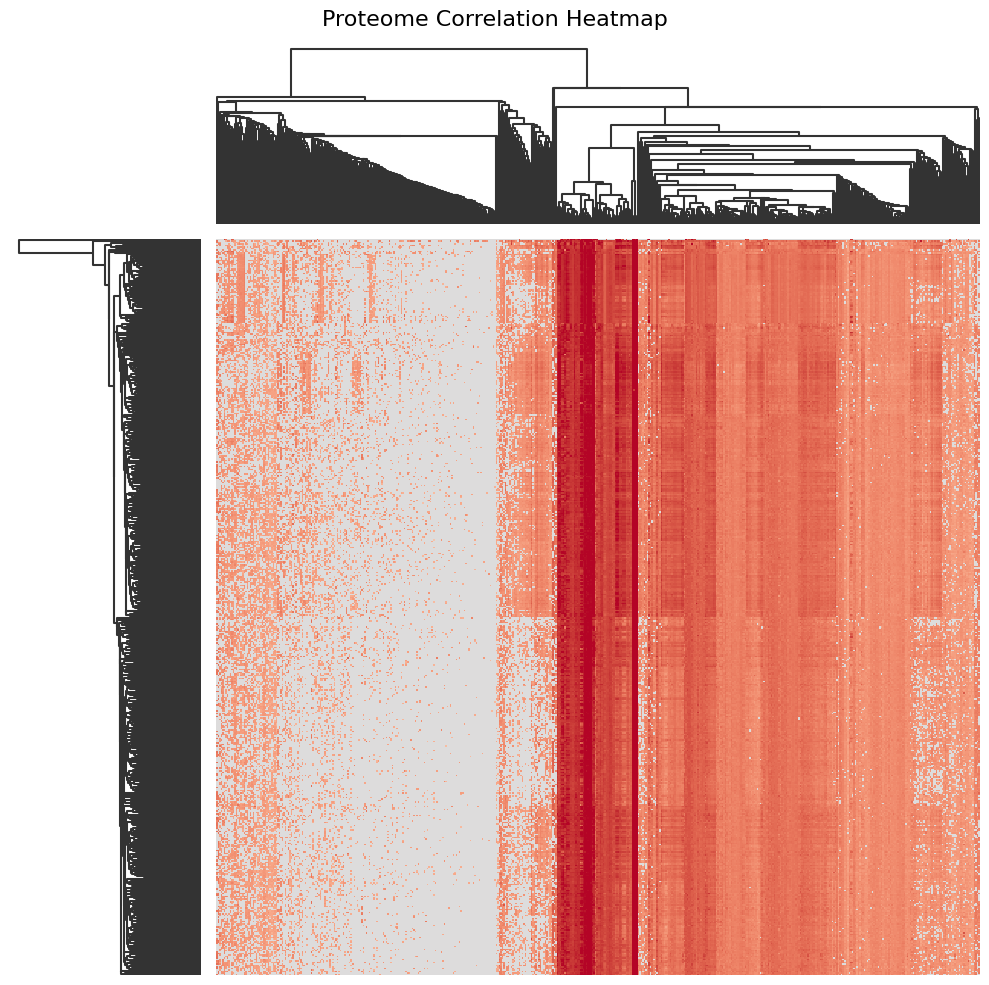

In [26]:
g = sns.clustermap(df.iloc[:500,:500].fillna(0),
            figsize=(10, 10),         # Move figsize here
            row_cluster=True,         # Cluster rows (samples)
            col_cluster=True,         # Cluster columns (proteins)
            metric='euclidean',       # Distance metric ('euclidean', 'correlation', 'cosine')
            method='average',         # Linkage method ('single', 'complete', 'average', 'ward')
            cbar=False,
            cbar_pos=None,           # Add this to remove colorbar space
            dendrogram_ratio=(0.2, 0.2),  # Size ratio of dendrograms (row, col)
            tree_kws={'linewidths': 1.5},  # Dendrogram line width
            cmap='coolwarm',          # Color scheme (alternatives: 'viridis', 'RdBu_r', 'YlOrRd')
            xticklabels=False,        # Show protein names
            yticklabels=False,        # Show sample names
            linewidths=0.001,         # Add grid lines
            linecolor='gray',         # Grid line color
            square=False,             # Don't force square cells
            vmin=None,                # Min value for color scale (auto if None)
            vmax=None,                # Max value for color scale (auto if None)
            center=0,                 # Center of colormap (useful for diverging colormaps)
            robust=True,              # Use robust quantiles for color limits
        )                
# Customize the plot
g.fig.suptitle('Proteome Correlation Heatmap', fontsize=16, y=0.98)  # Use suptitle on the figure
# Adjust layout to prevent label cutoff
plt.tight_layout()
# Show the plot
plt.show()

c:\Users\jomueller\AppData\Local\anaconda3\envs\viz_env\lib\site-packages\seaborn\matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

c:\Users\jomueller\AppData\Local\anaconda3\envs\viz_env\lib\site-packages\seaborn\matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



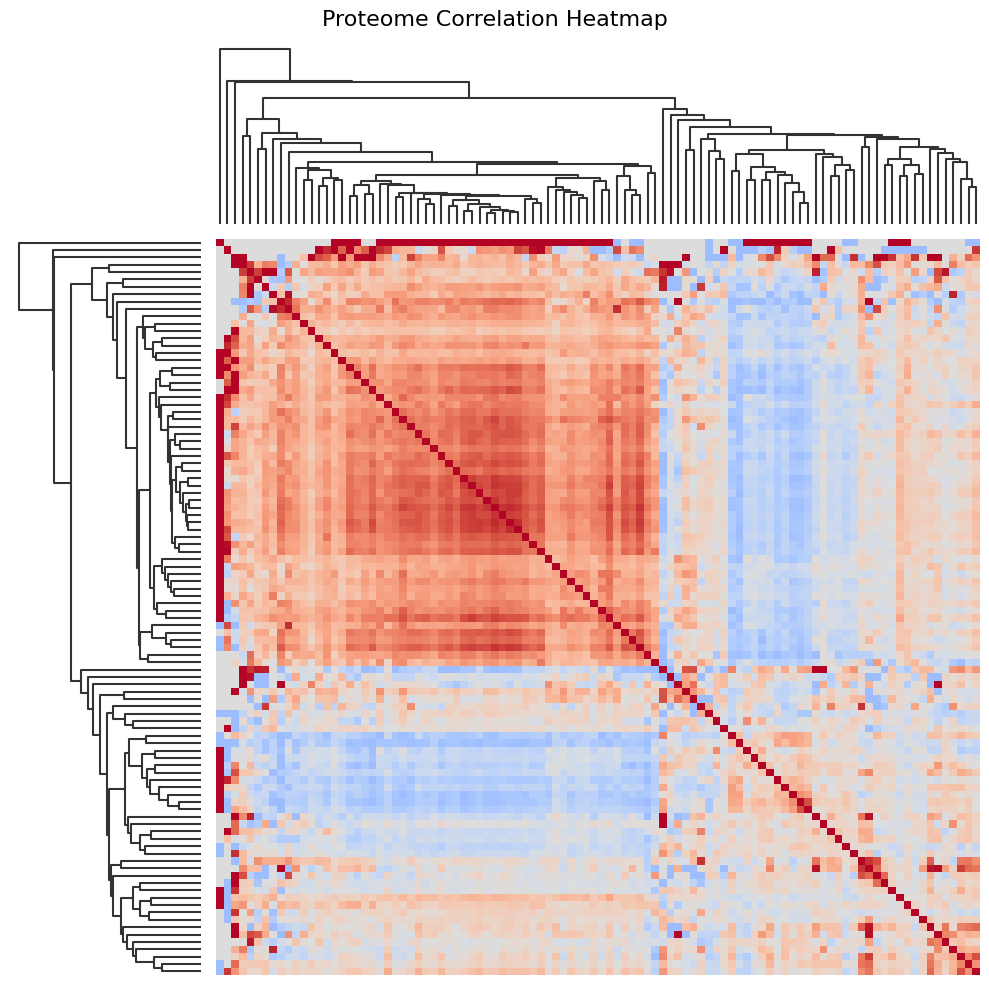

In [47]:
g = sns.clustermap(df.iloc[:,:100].corr().fillna(0),
            figsize=(10, 10),         # Move figsize here
            row_cluster=True,         # Cluster rows (samples)
            col_cluster=True,         # Cluster columns (proteins)
            metric='euclidean',       # Distance metric ('euclidean', 'correlation', 'cosine')
            method='average',         # Linkage method ('single', 'complete', 'average', 'ward')
            cbar=False,
            cbar_pos=None,           # Add this to remove colorbar space
            dendrogram_ratio=(0.2, 0.2),  # Size ratio of dendrograms (row, col)
            tree_kws={'linewidths': 1.5},  # Dendrogram line width
            cmap='coolwarm',          # Color scheme (alternatives: 'viridis', 'RdBu_r', 'YlOrRd')
            xticklabels=False,        # Show protein names
            yticklabels=False,        # Show sample names
            linewidths=0.00001,         # Add grid lines
            linecolor='gray',         # Grid line color
            square=False,             # Don't force square cells
            vmin=None,                # Min value for color scale (auto if None)
            vmax=None,                # Max value for color scale (auto if None)
            center=0,                 # Center of colormap (useful for diverging colormaps)
            robust=True,              # Use robust quantiles for color limits
        )                
# Customize the plot
g.fig.suptitle('Proteome Correlation Heatmap', fontsize=16, y=0.98)  # Use suptitle on the figure
# Adjust layout to prevent label cutoff
plt.tight_layout()
# Show the plot
plt.savefig(file_path / 'figures' / 'heatmap.pdf', dpi=300, bbox_inches='tight')

# save figures

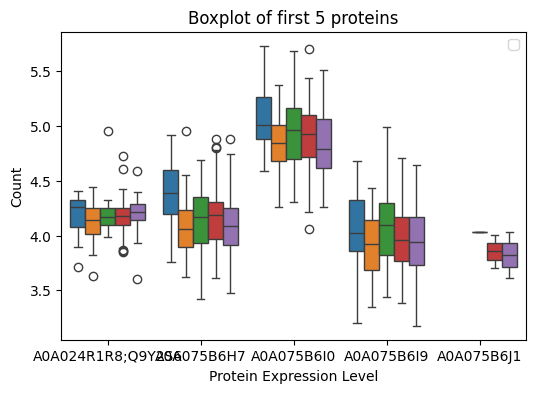

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(df_long[df_long['sct_description'].isin(d_meta['sct_description'].value_counts().iloc[:5].index)], y='value', hue='sct_description', x='variable')
plt.title('Boxplot of first 5 proteins')
plt.xlabel('Protein Expression Level')
plt.ylabel('Count')
plt.legend([])
plt.savefig(file_path / 'figures' / 'dummy_boxplot.png', dpi=300, bbox_inches='tight')

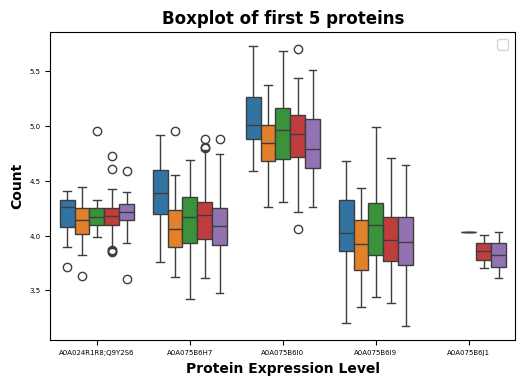

In [45]:
plt.figure(figsize=(6, 4))
sns.boxplot(df_long[df_long['sct_description'].isin(d_meta['sct_description'].value_counts().iloc[:5].index)], y='value', hue='sct_description', x='variable')
plt.title('Boxplot of first 5 proteins', fontsize=12, fontweight='bold')
plt.xlabel('Protein Expression Level', fontsize=10, fontweight='bold')
plt.xticks(rotation=0, fontsize=5)
plt.yticks(rotation=0, fontsize=5)
plt.ylabel('Count', fontsize=10, fontweight='bold')
plt.legend([])
plt.savefig(file_path / 'figures' / 'dummy_boxplot.pdf', dpi=300, bbox_inches='tight')


In [94]:
import plotly.express as px
fig = px.box(df_long[df_long['sct_description'].isin(d_meta['sct_description'].value_counts().iloc[:5].index)],
             y='value', color='sct_description', x='variable',
             title='Boxplot of first 5 proteins',
             points='all')
fig.show()

fig.update_layout(
    width=800,
    height=600,
    xaxis_tickangle=-90
)

fig.write_image(file_path / 'figures' / "boxplot_proteins.png", width=800, height=600, scale=2)

In [96]:
fig.write_html(file_path / 'figures' / "boxplot_proteins.html", include_plotlyjs='cdn')

c:\Users\jomueller\AppData\Local\anaconda3\envs\viz_env\lib\site-packages\seaborn\matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap

c:\Users\jomueller\AppData\Local\anaconda3\envs\viz_env\lib\site-packages\seaborn\matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

c:\Users\jomueller\AppData\Local\anaconda3\envs\viz_env\lib\site-packages\seaborn\matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



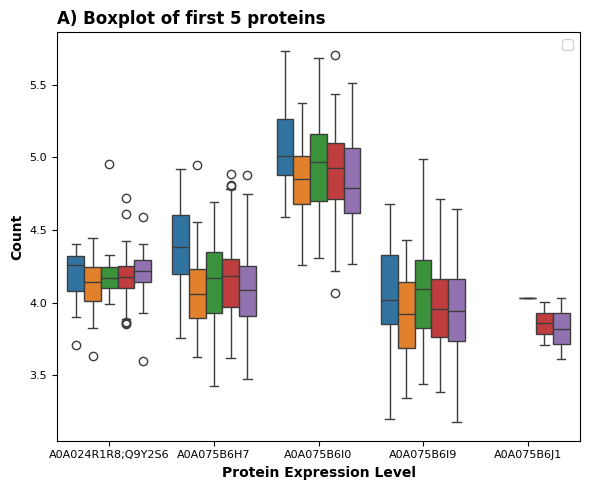

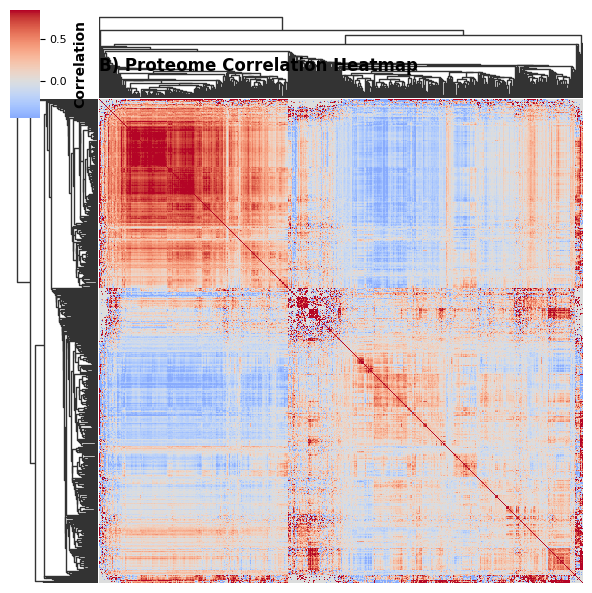

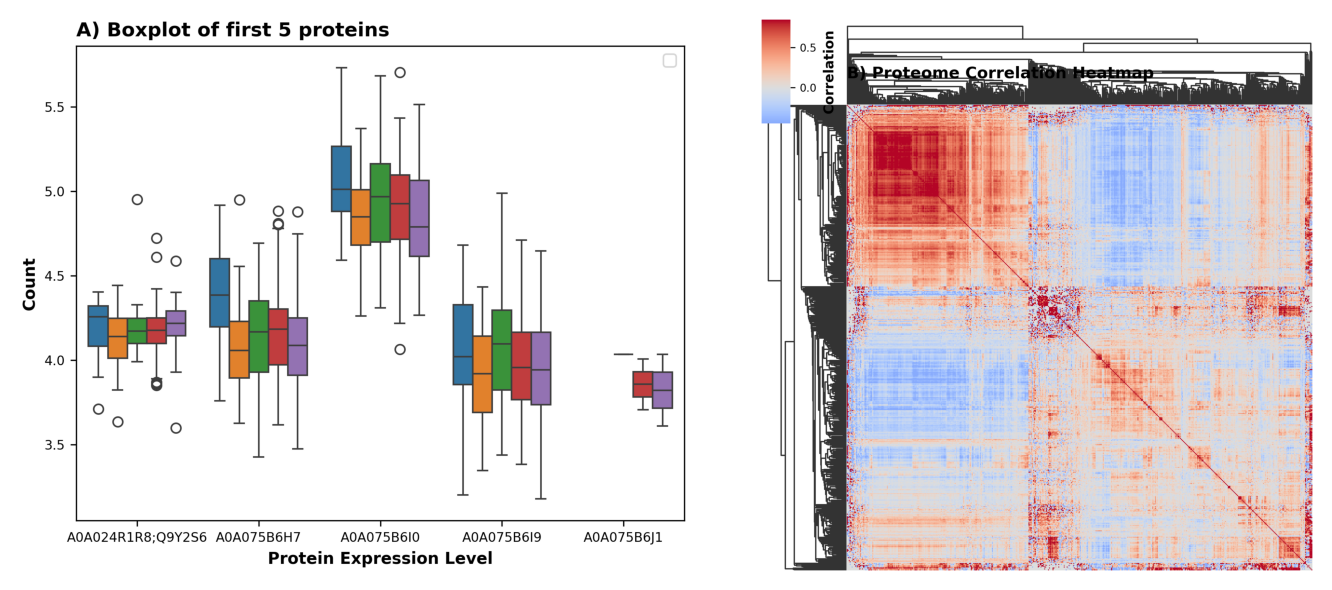

In [41]:
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec

# Create two separate figures first
# Figure 1: Boxplot
fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df_long[df_long['sct_description'].isin(d_meta['sct_description'].value_counts().iloc[:5].index)], 
            y='value', hue='sct_description', x='variable', ax=ax1)
ax1.set_title('A) Boxplot of first 5 proteins', fontsize=12, fontweight='bold', loc='left')
ax1.set_xlabel('Protein Expression Level', fontsize=10, fontweight='bold')
ax1.set_ylabel('Count', fontsize=10, fontweight='bold')
ax1.tick_params(axis='both', labelsize=8)
ax1.legend([])
plt.tight_layout()

# Figure 2: Clustermap
g = sns.clustermap(df.iloc[:,:500].corr().fillna(0),
                   figsize=(6, 6),
                   row_cluster=True,
                   col_cluster=True,
                   metric='euclidean',
                   method='average',
                   cbar=True,
                   cbar_kws={'label': 'Correlation'},
                   dendrogram_ratio=(0.15, 0.15),
                   tree_kws={'linewidths': 1.0},
                   cmap='coolwarm',
                   xticklabels=False,
                   yticklabels=False,
                   linewidths=0.00001,
                   linecolor='gray',
                   center=0,
                   robust=True,
                   square=True)

g.ax_heatmap.set_title('B) Proteome Correlation Heatmap', fontsize=12, fontweight='bold', loc='left', pad=20)
g.cax.set_ylabel('Correlation', fontsize=10, fontweight='bold')
g.cax.tick_params(labelsize=8)

# Save as temporary files
fig1.savefig('temp_boxplot.png', dpi=300, bbox_inches='tight')
g.savefig('temp_heatmap.png', dpi=300, bbox_inches='tight')

# Create combined figure by loading and displaying the images
from PIL import Image
import numpy as np

# Load images
img1 = Image.open('temp_boxplot.png')
img2 = Image.open('temp_heatmap.png')

# Create new figure for combined image
fig_combined = plt.figure(figsize=(14, 6))

# Display images side by side
ax_img1 = plt.subplot(1, 2, 1)
ax_img1.imshow(img1)
ax_img1.axis('off')

ax_img2 = plt.subplot(1, 2, 2)
ax_img2.imshow(img2)
ax_img2.axis('off')

plt.tight_layout()
plt.savefig(file_path / 'figures' / 'multi_panel_figure.png', dpi=300, bbox_inches='tight')
plt.show()

# Clean up temporary files
import os
os.remove('temp_boxplot.png')
os.remove('temp_heatmap.png')